1. Imports

In [1]:
import os
import time

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

print("PyTorch and torchvision imported successfully.")

PyTorch and torchvision imported successfully.


2. Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Device: cpu
Using CPU


3. Dataset + preprocessing + split

In [3]:
train_dir = r"D:\deep learning project\data\intel image classification\seg_train\seg_train"
test_dir = r"D:\deep learning project\data\intel image classification\seg_test\seg_test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 11227
Validation: 2807
Test: 3000


4. DataLoaders

In [4]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 351
Validation batches: 88
Test batches: 94


5. ResNet18 model

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze the pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classifier
model.fc = nn.Linear(model.fc.in_features, 6)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:12<00:00, 3.66MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

6. Parameter check

In [6]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11179590
Trainable parameters: 3078


7. Training + validation

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

EPOCHS = 5

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(EPOCHS):

    # --------------------
    # Training
    # --------------------
    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    # --------------------
    # Validation
    # --------------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Training Accuracy: {train_accuracy:.2f}% "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            r"D:\deep learning project\results\models\resnet18_best.pth"
        )

        print("Best model saved.")

Epoch [1/5] Training Accuracy: 82.03% Validation Accuracy: 89.35%
Best model saved.
Epoch [2/5] Training Accuracy: 89.20% Validation Accuracy: 89.81%
Best model saved.
Epoch [3/5] Training Accuracy: 89.50% Validation Accuracy: 90.24%
Best model saved.
Epoch [4/5] Training Accuracy: 89.74% Validation Accuracy: 90.92%
Best model saved.
Epoch [5/5] Training Accuracy: 90.02% Validation Accuracy: 88.92%


8. Test evaluation

In [8]:
# Load the best saved model
best_model_path = r"D:\deep learning project\results\models\resnet18_best.pth"

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 91.00%


9. Classification report

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

class_names = test_dataset.classes

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions:", len(all_preds))
print("Labels:", len(all_labels))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

Predictions: 3000
Labels: 3000

Classification Report:
              precision    recall  f1-score   support

   buildings     0.9159    0.8970    0.9064       437
      forest     0.9915    0.9873    0.9894       474
     glacier     0.8689    0.8391    0.8537       553
    mountain     0.8495    0.8495    0.8495       525
         sea     0.9291    0.9765    0.9522       510
      street     0.9149    0.9222    0.9185       501

    accuracy                         0.9100      3000
   macro avg     0.9116    0.9119    0.9116      3000
weighted avg     0.9096    0.9100    0.9097      3000



10. Confusion matrix

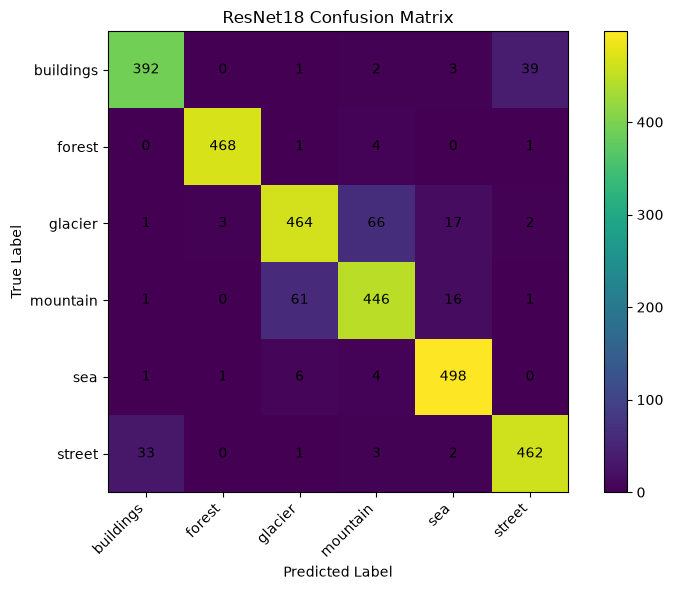

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("ResNet18 Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()